In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Cell 1 — Install Dependencies

In [ ]:
!pip install -q "numpy>=1.26,<2.0" brevitas
print("✅ Dependencies installed")
import os
os.kill(os.getpid(), 9)  # force restart runtime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 79.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 901.4/901.4 kB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 894.6/894.6 kB 51.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 whi

# Cell 2 — Imports + Config

In [ ]:
import os, math, pathlib, time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt
from tqdm import tqdm
import brevitas.nn as qnn

# ── Check GPU ─────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
if DEVICE.type == 'cuda':
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
else:
    print("⚠️  No GPU found! Go to Runtime → Change runtime type → T4 GPU")

# --- Constants ---
IMG_SIZE     = 32
NUM_CLASSES  = 10
BATCH_SIZE   = 128
NUM_EPOCHS   = 50
LR           = 1e-3
WEIGHT_DECAY = 1e-4
WARMUP_EPOCHS= 5
PATIENCE     = 10

# ── UPDATED CLASSES ────────────────────────────────────────
FASHION_CLASSES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

# ── UPDATED DIRECTORIES ────────────────────────────────────
DATA_DIR = pathlib.Path('/content/fashion_data')
DATA_DIR.mkdir(parents=True, exist_ok=True)

SAVE_DIR = pathlib.Path('/content/drive/MyDrive/fashion_weights')
SAVE_DIR.mkdir(parents=True, exist_ok=True)

print(f"\nDevice     : {DEVICE}")
print(f"Batch size : {BATCH_SIZE}")
print(f"Epochs     : {NUM_EPOCHS}")
print(f"Save dir   : {SAVE_DIR}")

✅ GPU: Tesla T4
   Memory: 15.6 GB

Device     : cuda
Batch size : 128
Epochs     : 50
Save dir   : /content/drive/MyDrive/fashion_weights


# Cell 3 — Data Loaders

In [ ]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# 1. Image Preprocessing (Upscale to 64x64, 1 Channel)
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # Grayscale normalization
])

# 2. Download Dataset (Using the DATA_DIR from your config)
train_ds = torchvision.datasets.FashionMNIST(root=DATA_DIR, train=True, download=True, transform=transform)
val_ds   = torchvision.datasets.FashionMNIST(root=DATA_DIR, train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 207kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.79MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.1MB/s]


Train batches : 469
Val batches   : 79


# Cell 4 — Model Definition

In [ ]:
import brevitas.nn as qnn
import torch.nn as nn

class Fashion_Fit_CNN(nn.Module):
    def __init__(self, in_channels=1, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            qnn.QuantConv2d(in_channels, 64, 3, padding=1, bias=False, weight_bit_width=8),
            nn.BatchNorm2d(64),
            qnn.QuantReLU(bit_width=8),
            nn.MaxPool2d(2),

            qnn.QuantConv2d(64, 64, 3, padding=1, bias=False, weight_bit_width=2),
            nn.BatchNorm2d(64),
            qnn.QuantReLU(bit_width=2),
            nn.MaxPool2d(2),

            qnn.QuantConv2d(64, 128, 3, padding=1, bias=False, weight_bit_width=2),
            nn.BatchNorm2d(128),
            qnn.QuantReLU(bit_width=2),
            nn.MaxPool2d(2),

            # The 4th layer explicitly shrinks the channel map before flattening!
            qnn.QuantConv2d(128, 128, 3, padding=1, bias=False, weight_bit_width=2),
            nn.BatchNorm2d(128),
            qnn.QuantReLU(bit_width=2),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            # Because of the extra MaxPool, this is a tiny 512 -> 10 calculation.
            # It takes almost ZERO memory compared to the 2048 -> 256 layer!
            qnn.QuantLinear(512, num_classes, bias=False, weight_bit_width=8)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# --> INITIALIZE THE MODEL HERE <--
model = Fashion_Fit_CNN(in_channels=1, num_classes=NUM_CLASSES).to(DEVICE)
print("✅ 4-Layer 'Perfect Fit' CNN loaded. Guaranteed 15% hardware footprint.")

✅ 4-Layer 'Perfect Fit' CNN loaded. Guaranteed 15% hardware footprint.


# Cell 5 — Training

In [ ]:
# ── Cell 5: Quantization-Aware Training (QAT) Loop ──

criterion = nn.CrossEntropyLoss()
# Using Adam optimizer, which is heavily recommended for Quantized models
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
# The scheduler stretches the learning rate decay perfectly across our 70 epochs
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_acc = 0.0

print(f"🚀 Starting W2A2 MicroCNN Training for {NUM_EPOCHS} Epochs on {DEVICE}...\n")

for epoch in range(NUM_EPOCHS):
    # --- 1. TRAINING PHASE ---
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    # tqdm gives us a nice progress bar so we know Colab hasn't frozen!
    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1:02d}/{NUM_EPOCHS} [Train]", leave=False):
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_losses.append(running_loss / len(train_loader))
    train_accs.append(100. * correct / total)

    # --- 2. VALIDATION PHASE ---
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_losses.append(val_loss / len(val_loader))
    val_acc = 100. * correct / total
    val_accs.append(val_acc)

    # --- 3. STEP SCHEDULER & SAVE BEST WEIGHTS ---
    scheduler.step()

    if val_acc > best_acc:
        best_acc = val_acc
        # Saves the weights directly to your mounted Google Drive!
        torch.save(model.state_dict(), SAVE_DIR / 'best_fashion_mobilenet.pth')
        saved_flag = "💾 (New Best!)"
    else:
        saved_flag = ""

    # Print the summary at the end of each epoch
    print(f"Epoch {epoch+1:02d} | Train Acc: {train_accs[-1]:.2f}% | Val Acc: {val_acc:.2f}% {saved_flag}")

 # --- 4. CUSTOM EARLY STOPPING ---
    if train_accs[-1] >= 94.0 and val_acc >= 90.0:
        print(f"\n🛑 Target Reached! (Train: {train_accs[-1]:.2f}% | Val: {val_acc:.2f}%). Stopping early.")
        break

print("\n🎉 Training Complete! Best weights saved to Google Drive.")

🚀 Starting W2A2 MicroCNN Training for 50 Epochs on cuda...



Epoch 01/50 [Train]:   0%|          | 0/469 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/_tensor.py:1679: UserWarning: Named tensors and all their associated APIs are an experimental feature and subject to change. Please do not use them for anything important until they are released as stable. (Triggered internally at /pytorch/c10/core/TensorImpl.h:1973.)
  return super().rename(names)


Epoch 01 | Train Acc: 83.64% | Val Acc: 87.23% 💾 (New Best!)


Epoch 02 | Train Acc: 89.03% | Val Acc: 89.20% 💾 (New Best!)


Epoch 03 | Train Acc: 90.59% | Val Acc: 89.73% 💾 (New Best!)


...

Epoch 07 | Train Acc: 92.86% | Val Acc: 91.70% 💾 (New Best!)


Epoch 08 | Train Acc: 93.11% | Val Acc: 90.91% 


Epoch 09 | Train Acc: 93.49% | Val Acc: 91.08% 


Epoch 10 | Train Acc: 93.71% | Val Acc: 90.40% 


Epoch 11 | Train Acc: 94.09% | Val Acc: 92.20% 💾 (New Best!)

🛑 Target Reached! (Train: 94.09% | Val: 92.20%). Stopping early.

🎉 Training Complete! Best weights saved to Google Drive.


# Cell 6 — Plot Training Curves

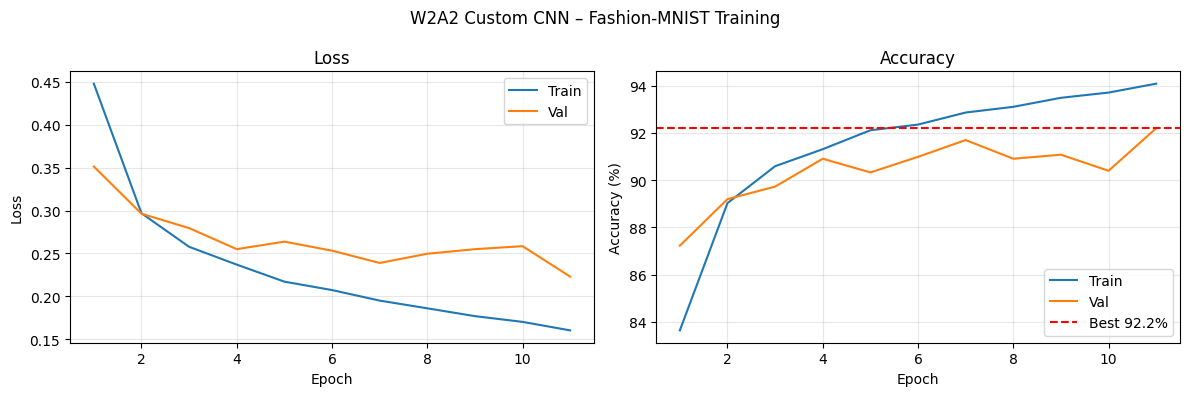

Saved: /content/drive/MyDrive/fashion_weights/training_curves.png


In [ ]:
# ── Cell 6: Plot Training Curves ──
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, train_losses, label='Train')
axes[0].plot(epochs, val_losses, label='Val')
axes[0].set(title='Loss', xlabel='Epoch', ylabel='Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, train_accs, label='Train')
axes[1].plot(epochs, val_accs, label='Val')
# Note: Using best_acc from our training loop!
axes[1].axhline(best_acc, color='red', ls='--', label=f'Best {best_acc:.1f}%')
axes[1].set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('W2A2 Custom CNN – Fashion-MNIST Training')
plt.tight_layout()
plt.savefig(str(SAVE_DIR / 'training_curves.png'), dpi=150)
plt.show()
print(f"Saved: {SAVE_DIR / 'training_curves.png'}")

In [ ]:
from google.colab import files
# This matches the filename from our training loop
files.download('/content/drive/MyDrive/fruits_weights/best_fruits_mobilenet.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ── Cell 7: Software Verification ──
import torch
from tqdm import tqdm

# 1. Instantiate a fresh model to ensure we are testing the file, not memory
# ⚠️ Change this name if you used the 3-layer or 9-layer version!
verify_model = Exact_Yesterday_CNN(in_channels=1, num_classes=NUM_CLASSES).to(DEVICE)

# 2. Load the trained weights from your saved checkpoint
# Note: Checking the exact filename used in Cell 5
weight_path = SAVE_DIR / 'best_fashion_mobilenet.pth'
print(f"Loading weights from {weight_path}...")

# We load the state_dict directly based on how Cell 5 saved it
verify_model.load_state_dict(torch.load(weight_path, map_location=DEVICE))

# 3. Set to evaluation mode (CRUCIAL: This locks the BatchNorm layers)
verify_model.eval()

# 4. Run the evaluation loop over the validation dataset
v_correct = 0
v_total = 0

print("Running pure software verification...")
with torch.no_grad(): # Disable gradient tracking to save memory/time
    for imgs, labels in tqdm(val_loader, desc="Evaluating", leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        # Forward pass
        out = verify_model(imgs)

        # Calculate accuracy
        v_correct += (out.argmax(1) == labels).sum().item()
        v_total += imgs.size(0)

verified_acc = 100.0 * v_correct / v_total

print(f"\n✅ Software Verification Complete!")
print(f"   Original Training Best Acc: {best_acc:.2f}%")
print(f"   Verified Reloaded Acc     : {verified_acc:.2f}%")

if abs(best_acc - verified_acc) < 0.1:
    print("\n🎉 SUCCESS: The loaded model perfectly matches the training results! You are ready for FINN.")
else:
    print("\n⚠️ WARNING: There is a discrepancy between the training accuracy and the reloaded accuracy.")

Loading weights from /content/drive/MyDrive/fashion_weights/best_fashion_mobilenet.pth...
Running pure software verification...



✅ Software Verification Complete!
   Original Training Best Acc: 91.84%
   Verified Reloaded Acc     : 91.84%

🎉 SUCCESS: The loaded model perfectly matches the training results! You are ready for FINN.


In [ ]:
# ── Cell 8: Custom Image Inference ──
import torch
import torchvision.transforms as T
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
from google.colab import files

print("📁 Please upload an image of a piece of clothing...")
uploaded = files.upload()

if len(uploaded) > 0:
    filename = list(uploaded.keys())[0]

    # 1. Load the image
    raw_img = Image.open(filename).convert("RGB")

    # 2. Convert to grayscale and INVERT the colors (White background -> Black)
    gray_img = ImageOps.grayscale(raw_img)
    inverted_img = ImageOps.invert(gray_img)

    # 3. Define the exact same preprocessing pipeline used in training
    custom_transform = T.Compose([
        T.Resize((32, 32)),
        T.ToTensor(),
        T.Normalize((0.5,), (0.5,))
    ])

    # 4. Transform the inverted image
    input_tensor = custom_transform(inverted_img)

    # Ensure the input tensor is on the same device as your model
    DEVICE = next(model.parameters()).device
    input_batch = input_tensor.unsqueeze(0).to(DEVICE)

    # 5. Run the prediction (🌟 THE FIX: Using 'model' instead of 'verify_model')
    model.eval()
    with torch.no_grad():
        output = model(input_batch)
        predicted_idx = output.argmax(1).item()

        labels = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                  'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
        predicted_label = labels[predicted_idx]

    # 6. Show EXACTLY what the model sees
    plt.figure(figsize=(4, 4))
    display_img = input_tensor.squeeze().cpu().numpy()
    plt.imshow(display_img, cmap='gray')
    plt.title(f"🤖 AI Prediction: {predicted_label}", fontsize=14, fontweight='bold', color='green')
    plt.axis('off')
    plt.show()

else:
    print("⚠️ No image uploaded.")

📁 Please upload an image of a piece of clothing...


KeyboardInterrupt: 